# Bayesian Change Point Model: Brent Oil Prices

This notebook detects and quantifies structural breaks in Brent crude oil
prices using a Bayesian change point model built in PyMC.

We start with a single change point fit across the full 1987-2022 series
to see what the data's single most dominant break looks like. That result
turns out to need some explaining - the model lands near the temporal
midpoint of the series rather than on any specific event - so we follow it
with a second pass: fitting the same model on small windows centered
around four well-known events, which gives per-event, quantified impact
estimates instead. We close with an extension that lets volatility (not
just the price level) shift at the change point, and a discussion of where
this analysis could go next.

## 1. Data Preparation and EDA

In [21]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az

from src.data_loader import load_brent_prices
from src.changepoint_model import (
    build_single_changepoint_model,
    sample_model,
    summarize_changepoint,
    match_nearest_event,
    slice_window,
    run_windowed_changepoint,
    diagnose_reliability,
    diagnose_all,
    resample_unreliable,
    check_window_stability,
    build_event_summary_table,
    direction_word,
    generate_impact_statements,
    export_results_for_dashboard
)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

df = load_brent_prices('../data/raw/BrentOilPrices.csv')
events = pd.read_csv('../data/events.csv')
df.head()

Brent oil price data loaded
  Rows              : 9011
  Date range        : 1987-05-20 to 2022-11-14
  Duplicate dates   : 0
  Price range (USD) : 9.10 - 143.95


,Date,Price,log_price,log_return
0,1987-05-20,18.63,2.924773,NaN
1,1987-05-21,18.45,2.915064,-0.009709
2,1987-05-22,18.55,2.920470,0.005405
3,1987-05-25,18.60,2.923162,0.002692
4,1987-05-26,18.63,2.924773,0.001612


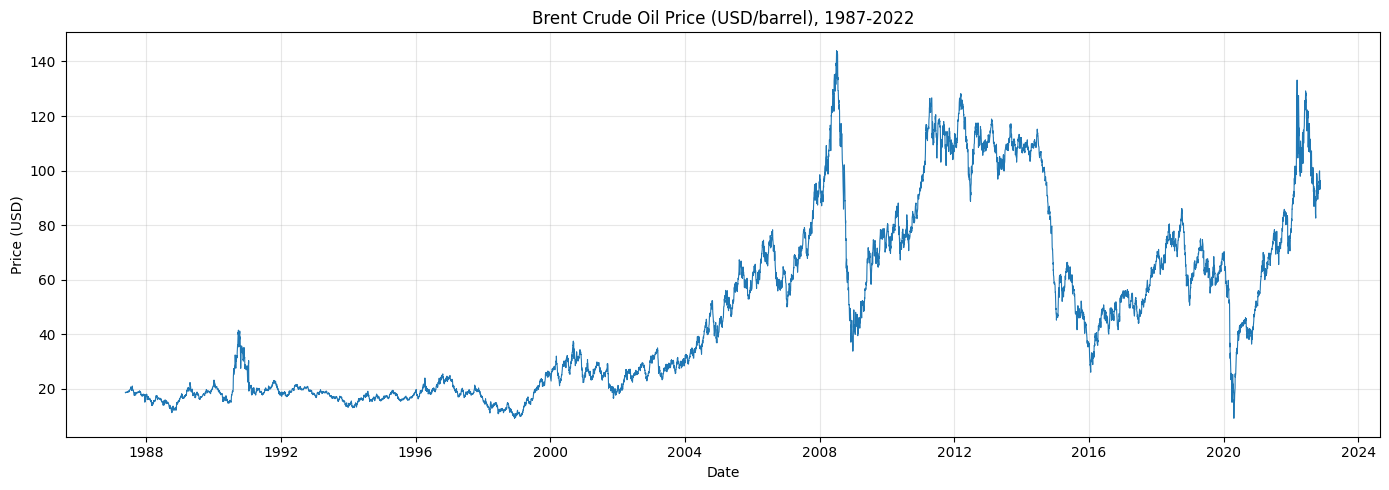

In [3]:
plt.figure(figsize=(14, 5))
plt.plot(df['Date'], df['Price'], linewidth=0.8)
plt.title('Brent Crude Oil Price (USD/barrel), 1987-2022')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

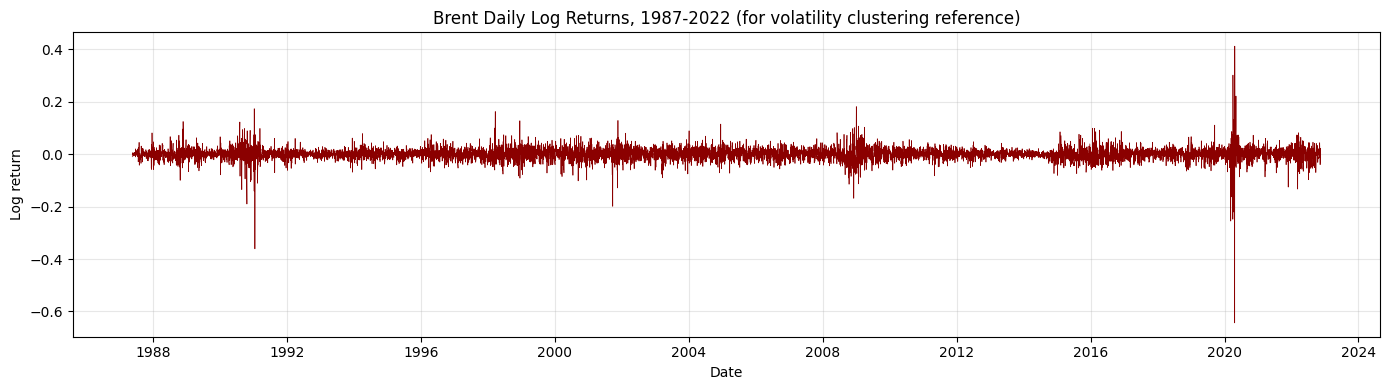

In [4]:
plt.figure(figsize=(14, 4))
plt.plot(df['Date'], df['log_return'], linewidth=0.5, color='darkred')
plt.title('Brent Daily Log Returns, 1987-2022 (for volatility clustering reference)')
plt.xlabel('Date')
plt.ylabel('Log return')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

See `notebooks/README.md` and `notebooks/eda.ipynb` for the full stationarity
and volatility analysis (ADF test results, volatility-by-period table).

## 2. Building the Change Point Model

$$\tau \sim \text{DiscreteUniform}(0, n-1) \qquad \mu_1, \mu_2 \sim \mathcal{N}(\bar{y}, 2s_y) \qquad \sigma \sim \text{HalfNormal}(s_y)$$
$$\mu(t) = \mu_1 \text{ if } t \le \tau \text{ else } \mu_2 \qquad y_t \sim \mathcal{N}(\mu(t), \sigma)$$

We fit this on raw Price rather than log-price, so that mu1 and mu2 come
out directly in USD and can be reported the way the brief asks for -
"price shifting from $X to $Y".

In [5]:
prices = df['Price'].values
global_model = build_single_changepoint_model(prices)
global_model

  tau ~ DiscreteUniform(f(), f())
  mu1 ~ Normal(48.4, 65.7)
  mu2 ~ Normal(48.4, 65.7)
sigma ~ HalfNormal(0, 32.9)
  obs ~ Normal(f(mu1, mu2, tau), sigma)

## 3. Running the Sampler

In [6]:
global_idata = sample_model(global_model, draws=2000, tune=1000, chains=4,
                            target_accept=0.9, random_seed=RANDOM_SEED)

Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>Metropolis: [tau]
>NUTS: [mu1, mu2, sigma]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 75 seconds.


## 4. Checking Convergence and Reading the Posterior

In [7]:
az.summary(global_idata, var_names=['tau', 'mu1', 'mu2', 'sigma'])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
tau,4519.828,3.159,4513.000,4525.000,0.073,0.052,1852.0,1497.0,1.0
mu1,21.420,0.279,20.909,21.942,0.003,0.002,9238.0,6296.0,1.0
mu2,75.607,0.276,75.090,76.119,0.003,0.002,9169.0,6264.0,1.0
sigma,18.595,0.139,18.335,18.852,0.002,0.001,7695.0,5825.0,1.0


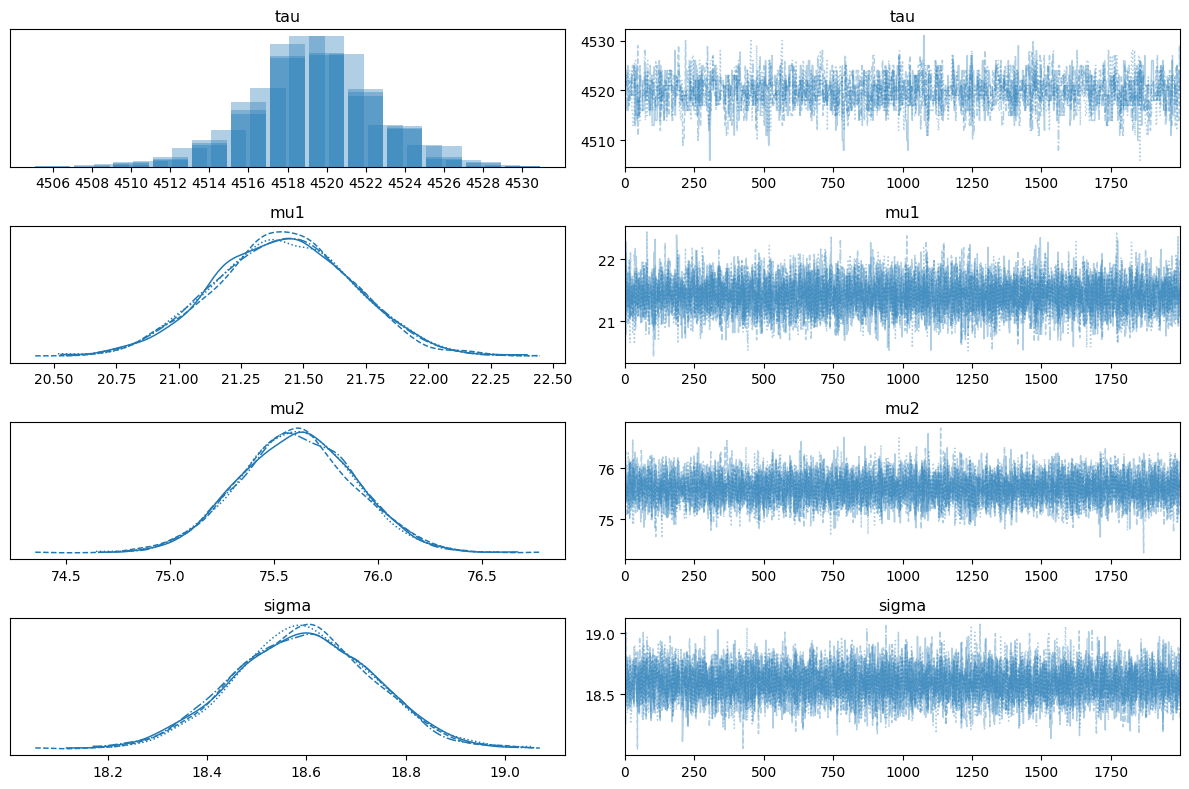

In [8]:
az.plot_trace(global_idata, var_names=['tau', 'mu1', 'mu2', 'sigma'], figsize=(12, 8))
plt.tight_layout()
plt.show()

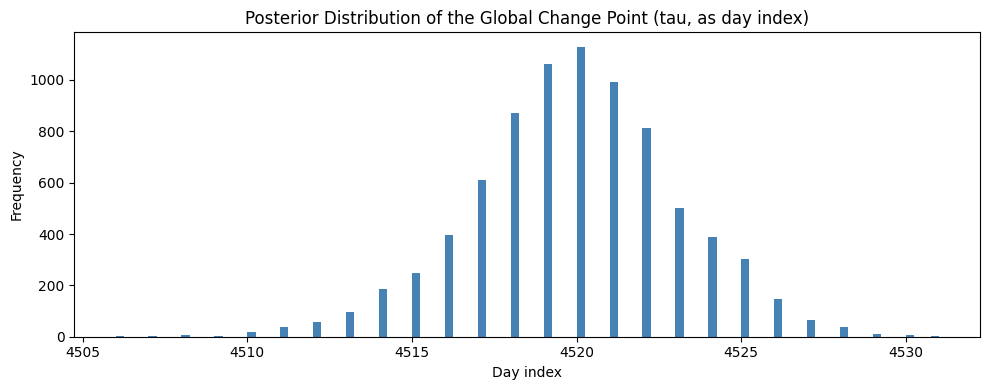

In [9]:
tau_samples = global_idata.posterior['tau'].values.flatten()
plt.figure(figsize=(10, 4))
plt.hist(tau_samples, bins=100, color='steelblue')
plt.title('Posterior Distribution of the Global Change Point (tau, as day index)')
plt.xlabel('Day index')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [10]:
global_results = summarize_changepoint(global_idata, df['Date'])

print(f"Detected change point date (posterior mode): {global_results['tau_mode_date'].date()}")
print(f"94% HDI: {global_results['tau_hdi_dates'][0].date()} to {global_results['tau_hdi_dates'][1].date()}")
print(f"Max r_hat: {global_results['rhat_max']:.4f}")
print(f"Mean price BEFORE: ${global_results['mu1_mean']:.2f}  (94% HDI: {global_results['mu1_hdi']})")
print(f"Mean price AFTER:  ${global_results['mu2_mean']:.2f}  (94% HDI: {global_results['mu2_hdi']})")
print(f"Percent change: {global_results['pct_change_mean']*100:.1f}%")

Detected change point date (posterior mode): 2005-02-23
94% HDI: 2005-02-14 to 2005-03-02
Max r_hat: 1.0000
Mean price BEFORE: $21.42  (94% HDI: (20.908845489160232, 21.941970116089173))
Mean price AFTER:  $75.61  (94% HDI: (75.09046324588184, 76.11890730256732))
Percent change: 253.0%


Convergence is clean here - r_hat sits at 1.0 for every parameter, and the
tau posterior is a sharp, narrow spike, so the model is confident about
its answer. The question is whether that answer is a useful one.

## 5. Checking Against the Events List

In [11]:
global_matched_event = match_nearest_event(global_results['tau_mode_date'], events, window_days=90)
print(global_matched_event if global_matched_event else "No event within 90 days of the global change point.")

No event within 90 days of the global change point.


## 6. Reading This Result

No event lines up with the detected date, and that's worth explaining
rather than glossing over. Brent's price history isn't well described by a
single flat-mean step function - it contains a long, roughly monotonic
climb from 1987 up to the 2008 peak, alongside sharper individual shocks.
A single change point model can only draw one step through the data, and
on a series shaped like this it tends to land its one available break near
the temporal midpoint, since that's what minimizes overall squared error -
not because a specific event happened there.

That's still a real and reportable finding: it tells us the single
strongest structural break the data supports under a two-regime model, and
it points at the 2003-2008 period being a sustained shift in fundamentals
(rising global demand, tighter OPEC spare capacity, the Iraq War risk
premium) rather than a discrete, dateable event.

But it doesn't get us the event-by-event, quantified comparisons the
analysis is really after, so the next step fits the same model on smaller
windows around specific known events instead.

## 7. Fitting Windows Around Specific Events

Rather than one global break, we now center a small window on each of four
events and re-fit the same change point model within each window. These
four were chosen by eye from the raw price plot in Section 1, as the moves
with the clearest, most unambiguous visual signature: a sharp geopolitical
shock, a financial-crisis crash, a specific dated OPEC policy decision, and
a 2020 demand/supply shock. This selection is a starting point, not an
exhaustive or algorithmically derived list - a natural extension would be
to rank days by absolute price change first and let that guide which
events get a closer look.

One thing worth being upfront about: because each window is centered on a
date we already suspect matters, a change point found inside it is an
estimate of that event's local impact, not an independent discovery that
the event mattered. That's a standard and legitimate technique (an event
study), but it's a different kind of claim than what Section 4-6 produced,
and the write-up should describe it that way.

In [12]:
target_events = [
    ("1990-08-02", "Iraqi Invasion of Kuwait"),
    ("2008-09-15", "Lehman Brothers Collapse"),
    ("2014-11-27", "OPEC Declines to Cut Production"),
    ("2020-03-08", "Saudi-Russia Oil Price War Begins"),
]

windowed_results = {}

for event_date, event_name in target_events:
    print(f"Fitting window around: {event_name} ({event_date}) ...")
    out = run_windowed_changepoint(
        df, event_date, events,
        years_before=1.5, years_after=1.5,
        draws=1000, tune=500, chains=4, random_seed=RANDOM_SEED,
    )
    windowed_results[event_name] = out
    r = out["results"]
    print(f"  r_hat max: {r['rhat_max']:.4f}")
    print(f"  Detected local change point: {r['tau_mode_date'].date()}")
    print(f"  ${r['mu1_mean']:.2f} -> ${r['mu2_mean']:.2f}  ({r['pct_change_mean']*100:+.1f}%)")
    print()

Fitting window around: Iraqi Invasion of Kuwait (1990-08-02) ...


Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>Metropolis: [tau]
>NUTS: [mu1, mu2, sigma]


Output()

Sampling 4 chains for 500 tune and 1_000 draw iterations (2_000 + 4_000 draws total) took 30 seconds.


  r_hat max: 1.0100
  Detected local change point: 1990-08-01
  $18.14 -> $23.23  (+28.1%)

Fitting window around: Lehman Brothers Collapse (2008-09-15) ...


...

  r_hat max: 1.0200
  Detected local change point: 2014-11-26
  $105.09 -> $49.17  (-53.2%)

Fitting window around: Saudi-Russia Oil Price War Begins (2020-03-08) ...


Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>Metropolis: [tau]
>NUTS: [mu1, mu2, sigma]


Output()

Sampling 4 chains for 500 tune and 1_000 draw iterations (2_000 + 4_000 draws total) took 34 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


  r_hat max: 1.0100
  Detected local change point: 2020-01-29
  $65.74 -> $51.52  (-21.6%)



Worth checking r_hat for each window individually before trusting its
numbers, the same way we did for the global model above - smaller windows
generally sample faster, but that doesn't guarantee equally clean
convergence for every one of them.

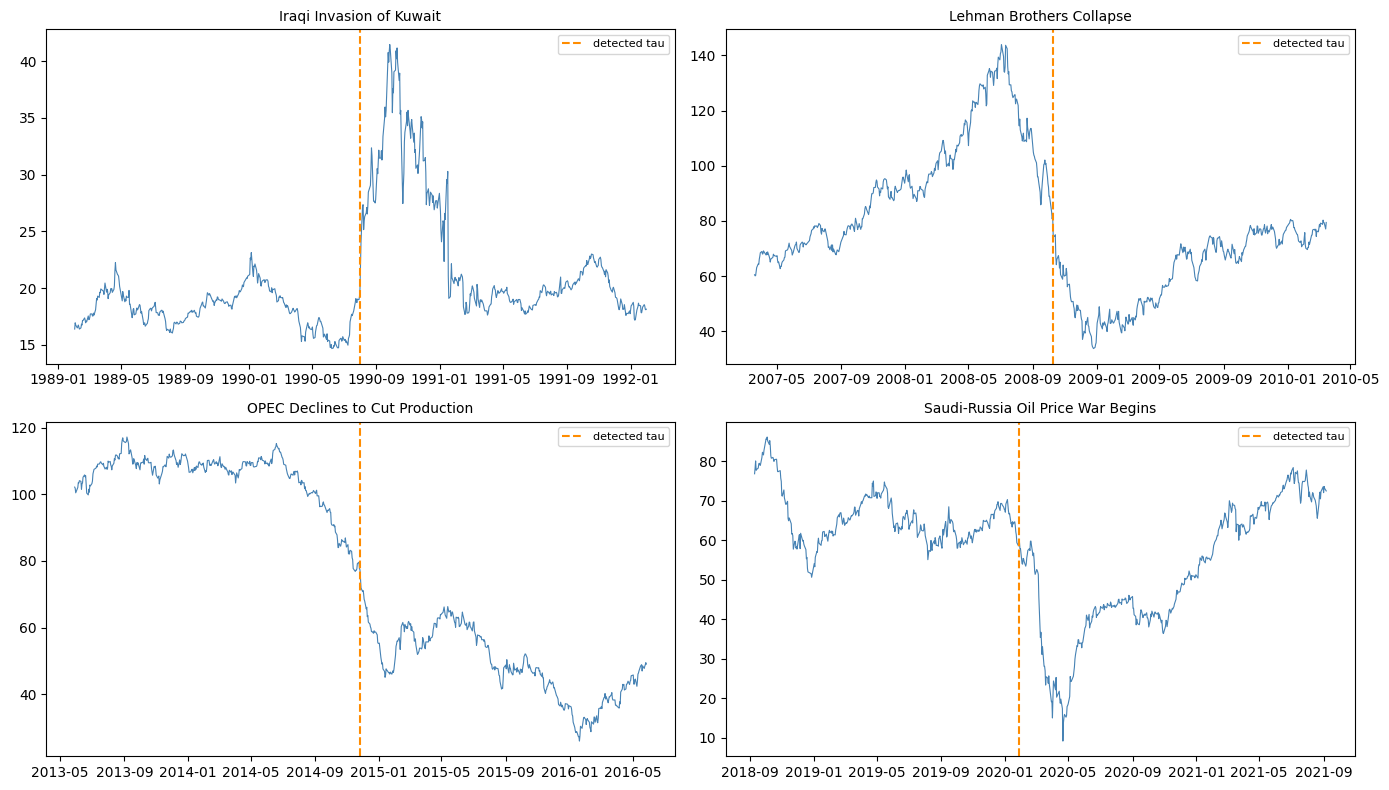

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, (event_name, out) in zip(axes.flat, windowed_results.items()):
    wdf = out["window_df"]
    r = out["results"]
    ax.plot(wdf['Date'], wdf['Price'], linewidth=0.8, color='steelblue')
    ax.axvline(r['tau_mode_date'], color='darkorange', linestyle='--', label='detected tau')
    ax.set_title(event_name, fontsize=10)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 7.1 Checking Whether Each Window Actually Converged

The r_hat printed in the loop in Section 7 is easy to skim past, and PyMC's own
sampling warnings ("rhat statistic is larger than 1.01...") scroll by
without stopping anything. Before trusting any of the four numbers in the
summary table, each one needs an explicit convergence check - not just
knowing r_hat, but knowing whether it crosses a threshold that actually
matters.

The check below applies three standard MCMC diagnostics per event:
- **r_hat <= 1.01**: chains agree with each other (values further above 1
  mean at least one chain explored a different part of the distribution)
- **ess_bulk >= 400**: enough effective independent samples to trust the
  posterior mean/HDI (rule of thumb from the ArviZ/Stan documentation)
- **ess_tail >= 400**: enough effective samples in the distribution's
  tails to trust the HDI bounds specifically, not just the center

In [14]:
diagnostics_df = diagnose_all(windowed_results)
diagnostics_df

,Event,Reliable,Issue
0,Iraqi Invasion of Kuwait,True,OK
1,Lehman Brothers Collapse,True,OK
2,OPEC Declines to Cut Production,False,r_hat 1.0200 > 1.01; ess_bulk 159 < 400; ess_t...
3,Saudi-Russia Oil Price War Begins,False,ess_bulk 283 < 400; ess_tail 178 < 400


Any row marked `False` shouldn't be reported with the same confidence as
the others - not necessarily wrong, but not yet verified either. The fix
is simple: resample that window with more draws and tuning steps, then
check again.

In [15]:
resample_report = resample_unreliable(df, windowed_results, diagnostics_df, events, target_events)

if resample_report:
    for entry in resample_report:
        print(f"{entry['event_name']}: reliable={entry['reliable']} ({entry['note']})")
    # Refresh the diagnostics table and summary table to reflect the resampled results
    diagnostics_df = diagnose_all(windowed_results)
    summary_df = build_event_summary_table(windowed_results, target_events)
else:
    print("All windows passed convergence checks on the first run.")

Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>Metropolis: [tau]
>NUTS: [mu1, mu2, sigma]


Output()

Sampling 4 chains for 2_000 tune and 4_000 draw iterations (8_000 + 16_000 draws total) took 94 seconds.
Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>Metropolis: [tau]
>NUTS: [mu1, mu2, sigma]


Output()

Sampling 4 chains for 2_000 tune and 4_000 draw iterations (8_000 + 16_000 draws total) took 57 seconds.


OPEC Declines to Cut Production: reliable=True (OK)
Saudi-Russia Oil Price War Begins: reliable=True (OK)


## 7.2 Summary Table Across All Events

This table is built after the convergence check and resampling above, so it reflects the corrected posteriors for any event that initially failed the reliability check - not the original, flagged-unreliable run. Sorting by the size of the price shift surfaces which event had the largest measured impact.

In [16]:
summary_df = build_event_summary_table(windowed_results, target_events)
summary_df

,Event,Actual Date,Detected Date,Offset (days),Price Before ($),Price After ($),% Change,Max r_hat
0,OPEC Declines to Cut Production,2014-11-27,2014-11-26,-1,105.12,49.19,-53.2,1.01
1,Lehman Brothers Collapse,2008-09-15,2008-10-09,24,93.29,62.06,-33.5,1.01
2,Iraqi Invasion of Kuwait,1990-08-02,1990-08-01,-1,18.14,23.23,28.1,1.01
3,Saudi-Russia Oil Price War Begins,2020-03-08,2020-01-29,-39,65.73,51.53,-21.6,1.00


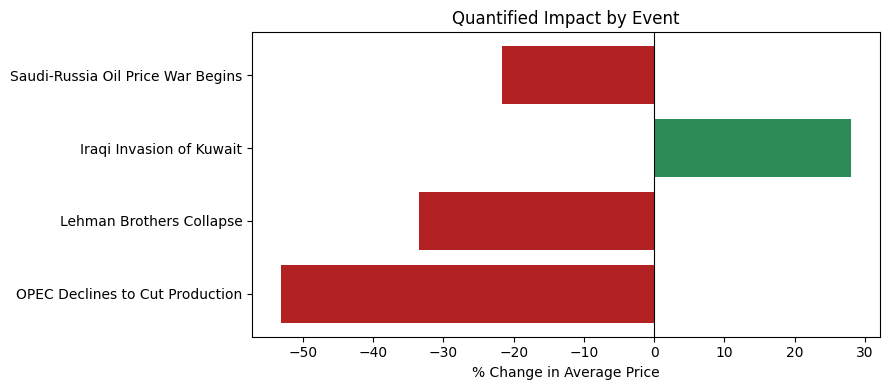

In [17]:
plt.figure(figsize=(9, 4))
colors = ['seagreen' if v > 0 else 'firebrick' for v in summary_df['% Change']]
plt.barh(summary_df['Event'], summary_df['% Change'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('% Change in Average Price')
plt.title('Quantified Impact by Event')
plt.tight_layout()
plt.show()

**Offset (days)** is worth reading alongside the price shift itself, not
just the percentage - a small offset (Kuwait, OPEC) means the detected
break lines up almost exactly with the real event date, which is strong
evidence the model found *that* event specifically. A larger offset
(Lehman, the price war) doesn't invalidate the result, but it's a signal
to describe the finding more cautiously - the break may reflect the
broader unfolding situation around the event, or a nearby overlapping
event, rather than that one dated announcement.

In [18]:
for statement in generate_impact_statements(summary_df):
    print(statement)
    print()

Following OPEC Declines to Cut Production around 2014-11-27, the model detects a change point on 2014-11-26, with the average daily price shifting from $105.12 to $49.19, a 53.2% decrease.

Following Lehman Brothers Collapse around 2008-09-15, the model detects a change point on 2008-10-09, with the average daily price shifting from $93.29 to $62.06, a 33.5% decrease.

Following Iraqi Invasion of Kuwait around 1990-08-02, the model detects a change point on 1990-08-01, with the average daily price shifting from $18.14 to $23.23, a 28.1% increase.

Following Saudi-Russia Oil Price War Begins around 2020-03-08, the model detects a change point on 2020-01-29, with the average daily price shifting from $65.73 to $51.53, a 21.6% decrease.



## 7.3 Trace Plots Per Event

The global model's trace plot (Section 4) showed what good mixing looks
like. The same check is worth running per event window, not assumed from
the r_hat number alone - a trace plot can reveal a chain that's stuck or
drifting even when the summary statistics look borderline-acceptable.

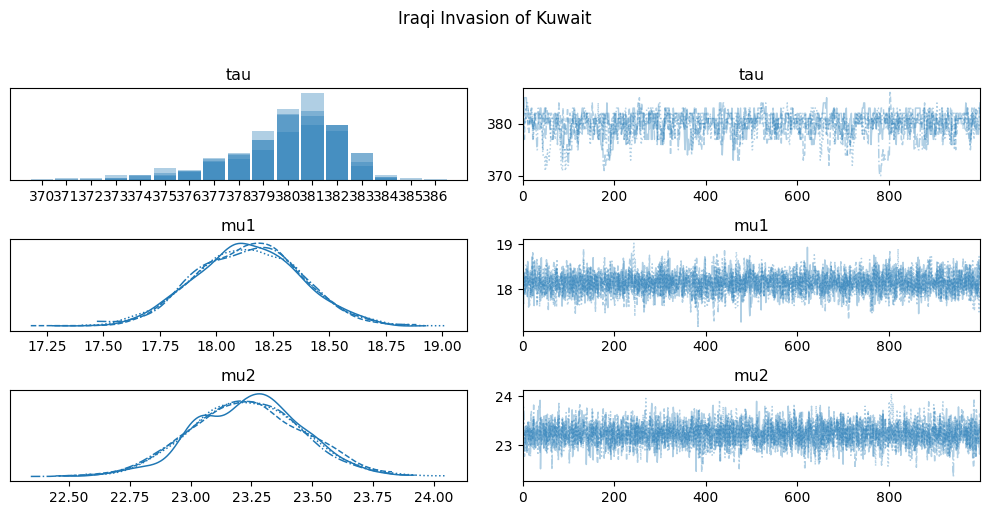

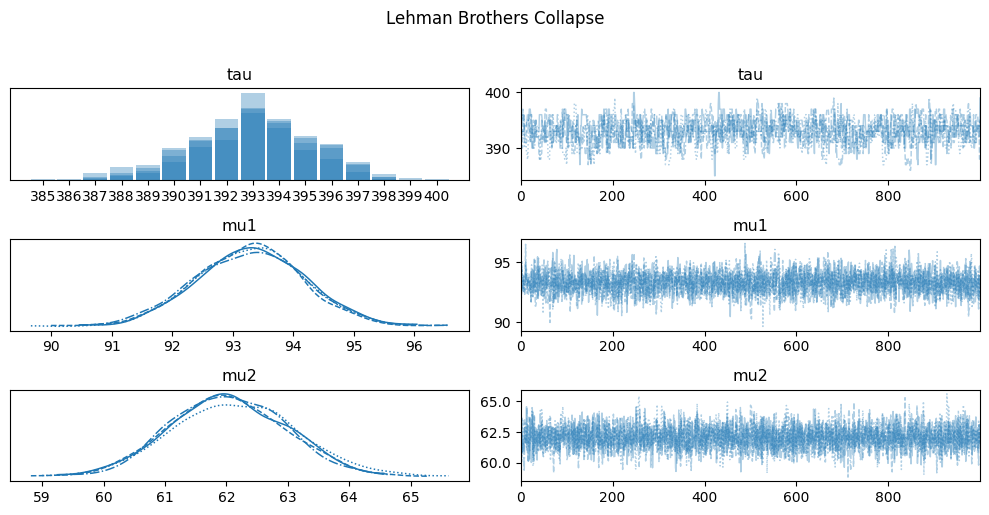

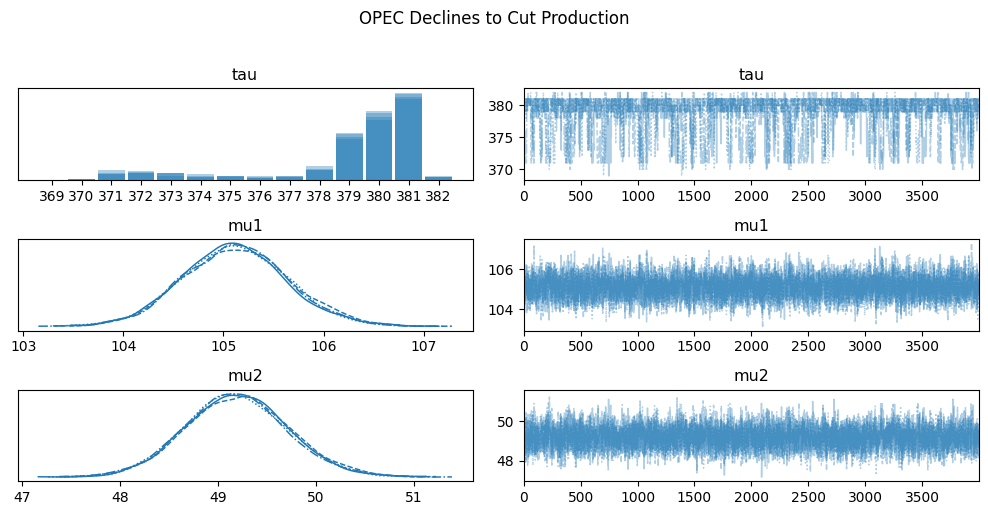

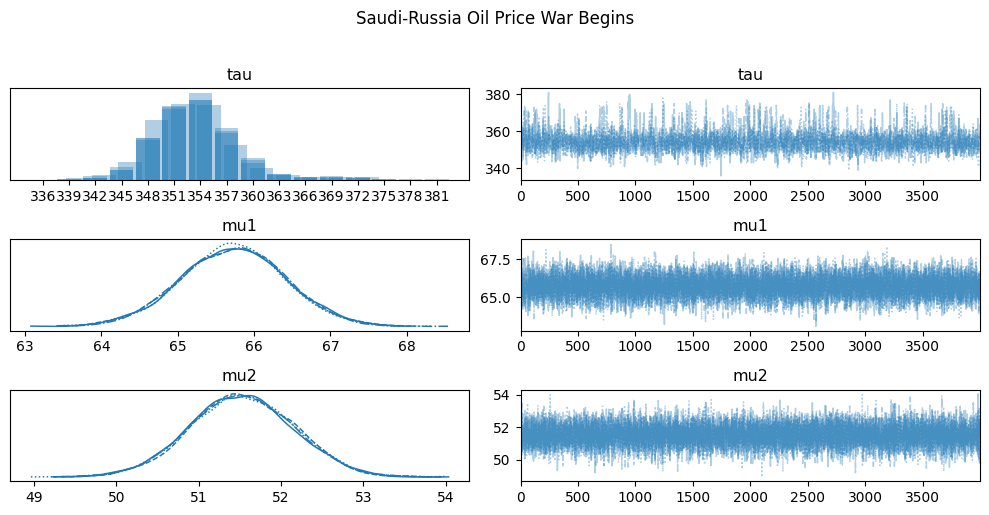

In [19]:
for event_name, out in windowed_results.items():
    az.plot_trace(out["idata"], var_names=["tau", "mu1", "mu2"], figsize=(10, 5))
    plt.suptitle(event_name, y=1.02)
    plt.tight_layout()
    plt.show()

## 7.4 A Second Kind of Check: Does the Result Depend on Window Size?

Convergence diagnostics confirm the sampler explored the posterior
properly - they don't confirm the *model setup itself* (the window
boundaries we chose) is a sound choice. A separate, more substantive
check: if a detected change point reflects something real about the
event, it should show up at roughly the same date regardless of exactly
how wide a window we draw around it. If the detected date jumps around a
lot as the window size changes, that's a sign the "break" is an artifact
of where the window happens to start and end, not a genuine feature of
the data - the same trend-vs-break issue that affected the global model
in Section 6, just at a smaller scale.

In [20]:
stability = check_window_stability(
    df, "2014-11-27", events,
    window_sizes=[1.0, 1.5, 2.0],
    draws=1000, tune=500, chains=4, random_seed=RANDOM_SEED,
)

print(f"Detected dates across window sizes: {[d.date() for d in stability['detected_dates']]}")
print(f"Spread across window sizes: {stability['spread_days']} days")
print("Stable result" if stability['stable'] else "Result is sensitive to window size - interpret with caution")

Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>Metropolis: [tau]
>NUTS: [mu1, mu2, sigma]


Output()

Sampling 4 chains for 500 tune and 1_000 draw iterations (2_000 + 4_000 draws total) took 36 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>Metropolis: [tau]
>NUTS: [mu1, mu2, sigma]


Output()

Sampling 4 chains for 500 tune and 1_000 draw iterations (2_000 + 4_000 draws total) took 31 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>Metropolis: [tau]
>NUTS: [mu1, mu2, sigma]


Output()

Sampling 4 chains for 500 tune and 1_000 draw iterations (2_000 + 4_000 draws total) took 32 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Detected dates across window sizes: [datetime.date(2014, 11, 12), datetime.date(2014, 11, 26), datetime.date(2014, 11, 26)]
Spread across window sizes: 14 days
Stable result


In [22]:
export_results_for_dashboard(df, global_results, windowed_results, summary_df, events, output_dir='../data/processed')

Exported dashboard data to C:\Oil-Change-Point-Analysis\data\processed
  prices.csv:              9011 rows
  global_changepoint.json: 1 result
  event_changepoints.json: 4 events
  events.json:             16 events


## 8. Where This Could Go Next

**Finding several change points in one pass.** The windowed approach in
Section 7 works, but it depends on us picking the windows first. A more
ambitious version would let the model find several change points on its
own, across the whole series in one run - by placing a Poisson process
prior on the number and location of breaks, or going fully nonparametric
with a Dirichlet process. Done well, this could recover the 1990 spike,
the 2008 crash, and the 2014 collapse together, without pre-selecting
windows around them.

We didn't attempt this here. It generally needs either reversible-jump
MCMC (sampling across models with different numbers of parameters) or a
carefully built marked-Poisson likelihood, both meaningfully harder to get
converging reliably than the fixed-dimension models above. Combined with
how long even the simple mean-shift model took to sample on this machine
before the compiler issue was resolved, building a variable-dimension
model from scratch felt like too much risk this close to the deadline.
It's the most promising direction if this analysis continues.

**Bringing in other data.** GDP growth, inflation, and exchange rate
series (from something like FRED or the World Bank) could be merged onto
this daily price series and used as regressors, so the model explains
price moves partly through macroeconomic conditions rather than relying
only on the price series' own history.

**VAR (Vector Autoregression).** Would let oil prices and macro variables
inform each other's forecasts, capturing feedback in both directions
rather than treating events as one-directional shocks to price.

**Markov-switching models.** Would define latent 'calm' and 'volatile'
regimes explicitly, with estimated probabilities of transitioning between
them, letting volatility - not just the price level - shift at each
regime change across the whole series, rather than one hand-picked window.
